##### Kylian YAMAMI - CentraleSupelec 3A MMF PFQ
# RL - Individual Assignment - Text Flappy Bird


## 1) Setup
Here I chose to work with the TextFlappyBird-v0 environment that returns the distance of the player from the center of the closest upcomig pipe gap along the two axes.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from collections import defaultdict

import text_flappy_bird_gym  # noqa: F401 - registers environments

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True



In [2]:
# Environment configuration (training level)
ENV_ID = "TextFlappyBird-v0"
ENV_CONFIG = {"height": 15, "width": 20, "pipe_gap": 4}
SEED = 42

# Shared experiment configuration
N_EPISODES = 5000
N_EVAL_EPISODES = 200
GAMMA = 0.99
MAX_STEPS_PER_EPISODE = 1000


def make_env(env_id=ENV_ID, env_config=None):
    if env_config is None:
        env_config = ENV_CONFIG
    return gym.make(env_id, **env_config)


env = make_env()
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)
obs, info = env.reset(seed=SEED)
print("Initial observation:", obs)
env.close()



Observation space: Tuple(Discrete(14), Discrete(22, start=-11))
Action space: Discrete(2)
Initial observation: (13, -3)


## 2) Utility Functions
Here we implement the better argmax function than numpy's one


In [3]:
def argmax_random_tie(q_values, rng):
    max_value = np.max(q_values)
    candidates = np.flatnonzero(q_values == max_value)
    return int(rng.choice(candidates))


def get_probs(Q_s, epsilon, nA, rng):
    # Same spirit as TP4 epsilon-soft policy, with random tie-breaking
    probs = np.ones(nA) * (epsilon / nA)
    best_a = argmax_random_tie(Q_s, rng)
    probs[best_a] += 1.0 - epsilon
    return probs


def epsilon_greedy_action(Q_s, epsilon, nA, rng):
    probs = get_probs(Q_s, epsilon, nA, rng)
    return rng.choice(np.arange(nA), p=probs)



In [4]:
# State helper for dictionary-based Q(s,a)

def canonical_state(state):
    x, y = state
    return (int(x), int(y))


def init_q_table(env):
    nA = env.action_space.n
    return defaultdict(lambda: np.zeros(nA, dtype=np.float64))



## 3) Monte Carlo Control (on-policy, first-visit)

### Principle
We generate full episodes with an $\epsilon$-greedy policy, then update $Q(s,a)$ from sampled returns.

### Return
$$
G_t = \sum_{k=0}^{T-t-1} \gamma^k R_{t+k+1}
$$

### First-visit MC update
$$
Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha \bigl(G_t - Q(S_t, A_t)\bigr)
$$
for the first occurrence of $(S_t, A_t)$ in the episode.



In [5]:
def generate_episode_from_Q(env, Q, epsilon, gamma, rng, max_steps_per_episode=1000):
    episode = []
    state, _ = env.reset()
    state = canonical_state(state)

    done = False
    steps = 0
    while not done and steps < max_steps_per_episode:
        nA = env.action_space.n
        # Sample action from current epsilon-greedy policy induced by Q
        action = epsilon_greedy_action(Q[state], epsilon, nA, rng)
        next_state, reward, terminated, truncated, _ = env.step(action)
        next_state = canonical_state(next_state)

        episode.append((state, action, reward))
        state = next_state
        done = terminated or truncated
        steps += 1

    return episode


def update_Q_first_visit_mc(Q, episode, alpha, gamma):
    G = 0.0
    visited = set()

    # Traverse the episode backward to accumulate return G_t
    for t in reversed(range(len(episode))):
        state_t, action_t, reward_t1 = episode[t]
        G = gamma * G + reward_t1
        key = (state_t, action_t)

        # First-visit MC: update only first occurrence of (s,a) in the episode
        if key not in visited:
            visited.add(key)
            Q[state_t][action_t] += alpha * (G - Q[state_t][action_t])


def mc_control(env_config, n_episodes, alpha=0.01, epsilon=0.1, gamma=0.99, seed=0, max_steps_per_episode=1000):
    env = make_env(env_config=env_config)
    Q = init_q_table(env)

    rng = np.random.default_rng(seed)

    episode_returns = []
    episode_lengths = []

    for _ in range(n_episodes):
        episode = generate_episode_from_Q(env, Q, epsilon, gamma, rng, max_steps_per_episode=max_steps_per_episode)
        update_Q_first_visit_mc(Q, episode, alpha, gamma)

        ep_return = sum(r for (_, _, r) in episode)
        episode_returns.append(ep_return)
        episode_lengths.append(len(episode))

    env.close()
    metrics = {
        "returns": np.asarray(episode_returns),
        "lengths": np.asarray(episode_lengths),
    }
    return Q, metrics



## 4) Sarsa(lambda) Tabular

### Principle
Sarsa($\lambda$) is an on-policy TD control method. It updates online at each step and uses eligibility traces to assign credit to recently visited state-action pairs.

### TD error
$$
\delta_t = R_{t+1} + \gamma Q(S_{t+1}, A_{t+1}) - Q(S_t, A_t)
$$

### Trace and value updates (accumulating traces)
$$
E_t(s,a) = \gamma\lambda E_{t-1}(s,a) + \mathbb{1}\{s=S_t, a=A_t\}
$$
$$
Q(s,a) \leftarrow Q(s,a) + \alpha\,\delta_t\,E_t(s,a)
$$



In [6]:
def sarsa_lambda_control(env_config, n_episodes, alpha=0.05, epsilon=0.1, lam=0.9, gamma=0.99, seed=0, max_steps_per_episode=1000):
    env = make_env(env_config=env_config)
    Q = init_q_table(env)

    nA = env.action_space.n
    rng = np.random.default_rng(seed)

    episode_returns = []
    episode_lengths = []

    for _ in range(n_episodes):
        # Eligibility traces stored per visited (state, action)
        E = defaultdict(float)

        state, _ = env.reset()
        state = canonical_state(state)
        action = epsilon_greedy_action(Q[state], epsilon, nA, rng)

        done = False
        ep_return = 0.0
        steps = 0

        while not done and steps < max_steps_per_episode:
            next_state, reward, terminated, truncated, _ = env.step(action)
            next_state = canonical_state(next_state)
            done = terminated or truncated

            ep_return += reward
            steps += 1

            q_sa = Q[state][action]

            if done:
                # Terminal target: no bootstrap term
                delta = reward - q_sa
                E[(state, action)] += 1.0

                # Apply trace-weighted update to all visited pairs
                for (s_e, a_e), e_val in list(E.items()):
                    Q[s_e][a_e] += alpha * delta * e_val
                break

            next_action = epsilon_greedy_action(Q[next_state], epsilon, nA, rng)
            delta = reward + gamma * Q[next_state][next_action] - q_sa

            # Accumulating trace for current pair
            E[(state, action)] += 1.0

            # Update all traced pairs, then decay traces by gamma*lambda
            for (s_e, a_e), e_val in list(E.items()):
                Q[s_e][a_e] += alpha * delta * e_val
                E[(s_e, a_e)] = gamma * lam * e_val

            state = next_state
            action = next_action

        episode_returns.append(ep_return)
        episode_lengths.append(steps)

    env.close()
    metrics = {
        "returns": np.asarray(episode_returns),
        "lengths": np.asarray(episode_lengths),
    }
    return Q, metrics



## 5) Evaluation + Plots
We evaluate each learned policy in greedy mode over multiple episodes. 
Learning curves report multi-run averages (with uncertainty), while value/policy maps show what each agent has learned over the state space.

In [7]:
def evaluate_greedy_policy(Q, env_config, n_episodes=200, seed=123, max_steps_per_episode=1000):
    env = make_env(env_config=env_config)
    rng = np.random.default_rng(seed)

    returns = []
    lengths = []

    for _ in range(n_episodes):
        state, _ = env.reset(seed=int(rng.integers(0, 10_000_000)))
        state = canonical_state(state)

        done = False
        ep_return = 0.0
        steps = 0

        while not done and steps < max_steps_per_episode:
            action = argmax_random_tie(Q[state], rng)
            next_state, reward, terminated, truncated, _ = env.step(action)
            state = canonical_state(next_state)

            done = terminated or truncated
            ep_return += reward
            steps += 1

        returns.append(ep_return)
        lengths.append(steps)

    env.close()
    return {
        "returns": np.asarray(returns),
        "lengths": np.asarray(lengths),
        "mean_return": float(np.mean(returns)),
        "std_return": float(np.std(returns)),
    }



In [8]:
def mean_and_sem(x):
    # x shape: [n_runs, n_steps]
    mean = np.mean(x, axis=0)
    if x.shape[0] <= 1:
        sem = np.zeros_like(mean)
    else:
        sem = np.std(x, axis=0, ddof=1) / np.sqrt(x.shape[0])
    return mean, sem


def bin_runs(x, bin_size=100):
    # x shape: [n_runs, n_steps] -> [n_runs, n_bins]
    n_runs, n_steps = x.shape
    n_bins = n_steps // bin_size
    if n_bins == 0:
        return x.copy(), np.arange(1, n_steps + 1)

    x_trim = x[:, : n_bins * bin_size]
    x_bin = x_trim.reshape(n_runs, n_bins, bin_size).mean(axis=2)
    centers = np.arange(n_bins) * bin_size + (bin_size / 2.0)
    return x_bin, centers


def plot_learning_curves(mc_runs_metrics, sarsa_runs_metrics, bin_size=100):
    mc_returns = np.array([m["returns"] for m in mc_runs_metrics])
    mc_lengths = np.array([m["lengths"] for m in mc_runs_metrics])

    sarsa_returns = np.array([m["returns"] for m in sarsa_runs_metrics])
    sarsa_lengths = np.array([m["lengths"] for m in sarsa_runs_metrics])

    # Bin episode curves to improve readability
    mc_ret_bin, x = bin_runs(mc_returns, bin_size=bin_size)
    mc_len_bin, _ = bin_runs(mc_lengths, bin_size=bin_size)
    s_ret_bin, _ = bin_runs(sarsa_returns, bin_size=bin_size)
    s_len_bin, _ = bin_runs(sarsa_lengths, bin_size=bin_size)

    mc_ret_mean, mc_ret_sem = mean_and_sem(mc_ret_bin)
    mc_len_mean, mc_len_sem = mean_and_sem(mc_len_bin)
    s_ret_mean, s_ret_sem = mean_and_sem(s_ret_bin)
    s_len_mean, s_len_sem = mean_and_sem(s_len_bin)

    c_mc = "#1f77b4"
    c_sarsa = "#d62728"

    fig, ax = plt.subplots(1, 2, figsize=(14, 4))

    # Return plot
    ax[0].fill_between(x, mc_ret_mean - mc_ret_sem, mc_ret_mean + mc_ret_sem, color=c_mc, alpha=0.16, zorder=1)
    ax[0].fill_between(x, s_ret_mean - s_ret_sem, s_ret_mean + s_ret_sem, color=c_sarsa, alpha=0.16, zorder=1)
    ax[0].plot(x, mc_ret_mean, color=c_mc, lw=2.4, zorder=3, label="MC Control")
    ax[0].plot(x, s_ret_mean, color=c_sarsa, lw=2.4, zorder=3, label="Sarsa(lambda)")
    ax[0].set_title(f"Episode Return (binned mean across runs, bin={bin_size})")
    ax[0].set_xlabel("Episode")
    ax[0].set_ylabel("Return")
    ax[0].legend(frameon=True)

    # Length plot
    ax[1].fill_between(x, mc_len_mean - mc_len_sem, mc_len_mean + mc_len_sem, color=c_mc, alpha=0.16, zorder=1)
    ax[1].fill_between(x, s_len_mean - s_len_sem, s_len_mean + s_len_sem, color=c_sarsa, alpha=0.16, zorder=1)
    ax[1].plot(x, mc_len_mean, color=c_mc, lw=2.4, zorder=3, label="MC Control")
    ax[1].plot(x, s_len_mean, color=c_sarsa, lw=2.4, zorder=3, label="Sarsa(lambda)")
    ax[1].set_title(f"Episode Length (binned mean across runs, bin={bin_size})")
    ax[1].set_xlabel("Episode")
    ax[1].set_ylabel("Length")
    ax[1].legend(frameon=True)

    plt.tight_layout()
    plt.show()


def q_dict_to_grids(Q, env_config):
    env = make_env(env_config=env_config)
    x_space = env.observation_space[0]
    y_space = env.observation_space[1]
    n_x = x_space.n
    n_y = y_space.n
    y_start = y_space.start
    env.close()

    V = np.zeros((n_x, n_y), dtype=np.float64)
    policy = np.zeros((n_x, n_y), dtype=np.int64)

    for ix in range(n_x):
        for iy in range(n_y):
            state = (ix, iy + y_start)
            q_s = Q[state]
            V[ix, iy] = np.max(q_s)
            policy[ix, iy] = int(np.argmax(q_s))

    return V, policy, y_start


def plot_value_and_policy(Q, env_config, title_prefix=""):
    V, policy, y_start = q_dict_to_grids(Q, env_config)
    n_x, n_y = V.shape

    fig, ax = plt.subplots(1, 2, figsize=(14, 4))

    im0 = ax[0].imshow(V.T, origin="lower", aspect="auto")
    ax[0].set_title(f"{title_prefix} Value Function V(s)")
    ax[0].set_xlabel("x_dist")
    ax[0].set_ylabel("y_dist")
    yticks = np.linspace(0, n_y - 1, min(n_y, 6), dtype=int)
    ax[0].set_yticks(yticks)
    ax[0].set_yticklabels([str(int(y + y_start)) for y in yticks])
    plt.colorbar(im0, ax=ax[0])

    im1 = ax[1].imshow(policy.T, origin="lower", aspect="auto", vmin=0, vmax=1)
    ax[1].set_title(f"{title_prefix} Greedy Policy (0=Idle, 1=Flap)")
    ax[1].set_xlabel("x_dist")
    ax[1].set_ylabel("y_dist")
    ax[1].set_yticks(yticks)
    ax[1].set_yticklabels([str(int(y + y_start)) for y in yticks])
    plt.colorbar(im1, ax=ax[1])

    plt.tight_layout()
    plt.show()



## 6) Train Both Agents (baseline)
We train both agents under the same baseline protocol (same seeds, same episode budget). This provides a direct initial comparison before hyperparameter tuning.


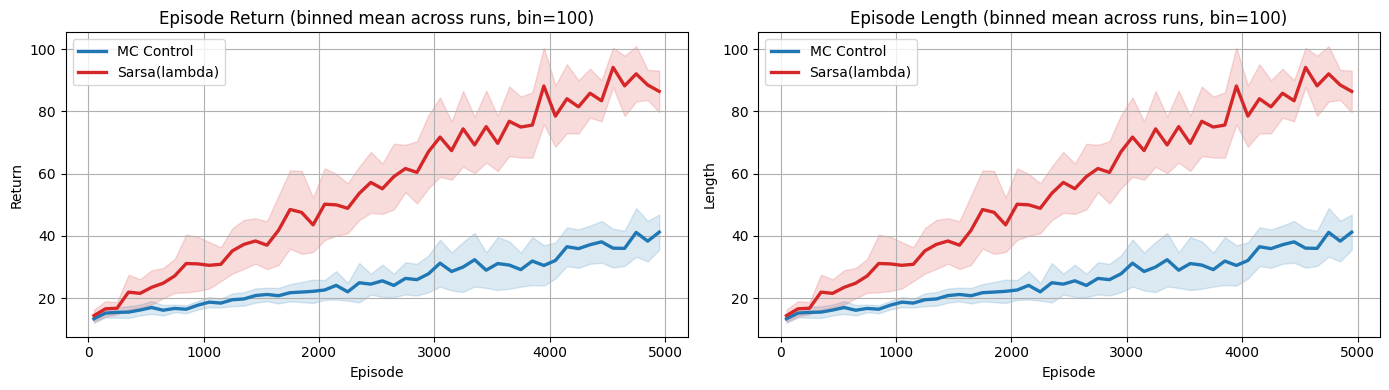

In [9]:
N_RUNS = 5

mc_params = {
    "alpha": 0.02,
    "epsilon": 0.1,
    "gamma": GAMMA,
    "max_steps_per_episode": MAX_STEPS_PER_EPISODE,
}

sarsa_params = {
    "alpha": 0.08,
    "epsilon": 0.1,
    "lam": 0.9,
    "gamma": GAMMA,
    "max_steps_per_episode": MAX_STEPS_PER_EPISODE,
}

mc_runs_metrics, sarsa_runs_metrics = [], []
mc_runs_Q, sarsa_runs_Q = [], []

for run_idx in range(N_RUNS):
    run_seed = SEED + run_idx
    Q_mc_run, metrics_mc_run = mc_control(ENV_CONFIG, N_EPISODES, seed=run_seed, **mc_params)
    Q_sarsa_run, metrics_sarsa_run = sarsa_lambda_control(ENV_CONFIG, N_EPISODES, seed=run_seed, **sarsa_params)

    mc_runs_Q.append(Q_mc_run)
    sarsa_runs_Q.append(Q_sarsa_run)
    mc_runs_metrics.append(metrics_mc_run)
    sarsa_runs_metrics.append(metrics_sarsa_run)

plot_learning_curves(mc_runs_metrics, sarsa_runs_metrics, bin_size=100)

# Keep one representative trained Q for value/policy plots and transfer tests
Q_mc = mc_runs_Q[-1]
Q_sarsa = sarsa_runs_Q[-1]




In [10]:
mc_eval_runs = []
sarsa_eval_runs = []

for run_idx in range(N_RUNS):
    mc_eval_runs.append(evaluate_greedy_policy(mc_runs_Q[run_idx], ENV_CONFIG, n_episodes=N_EVAL_EPISODES, seed=SEED + 100 + run_idx))
    sarsa_eval_runs.append(evaluate_greedy_policy(sarsa_runs_Q[run_idx], ENV_CONFIG, n_episodes=N_EVAL_EPISODES, seed=SEED + 200 + run_idx))

mc_means = np.array([e["mean_return"] for e in mc_eval_runs])
sarsa_means = np.array([e["mean_return"] for e in sarsa_eval_runs])

print("MC Control - eval mean over runs:", round(float(np.mean(mc_means)), 2), "+/-", round(float(np.std(mc_means, ddof=1)), 2))
print("Sarsa(lambda) - eval mean over runs:", round(float(np.mean(sarsa_means)), 2), "+/-", round(float(np.std(sarsa_means, ddof=1)), 2))



MC Control - eval mean over runs: 101.55 +/- 65.67
Sarsa(lambda) - eval mean over runs: 677.25 +/- 302.19


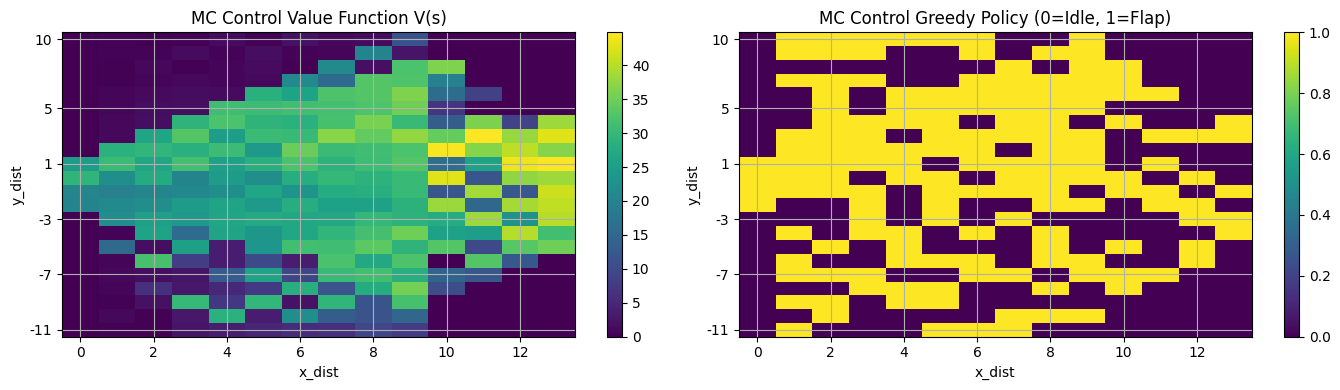

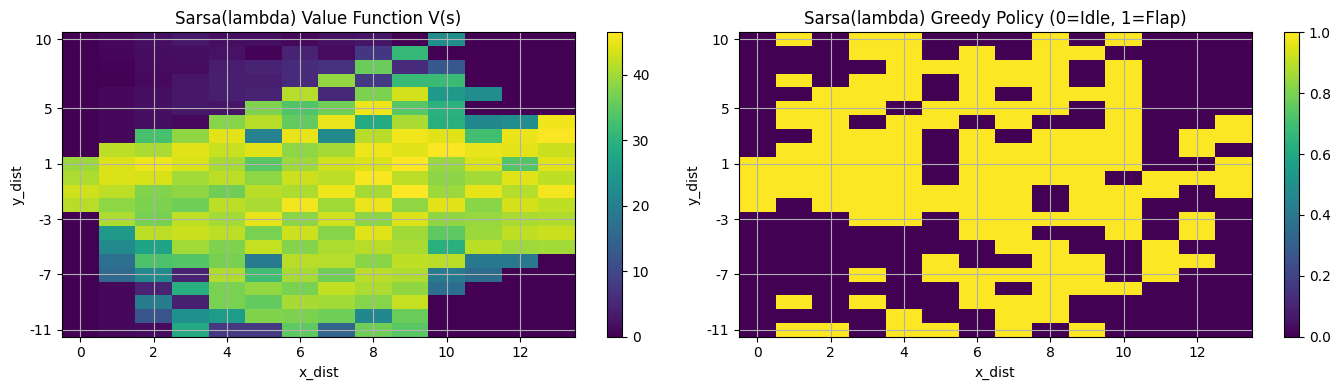

In [11]:
plot_value_and_policy(Q_mc, ENV_CONFIG, title_prefix="MC Control")
plot_value_and_policy(Q_sarsa, ENV_CONFIG, title_prefix="Sarsa(lambda)")


## 7) Parameter Sweeps
We analyze sensitivity to hyperparameters: alpha for MC and lambda for Sarsa(λ), first with a short grid and then with an extended grid. The best-performing settings are used in final tests.

In [12]:
def sweep_mc_alpha(alpha_list, n_episodes=2000, n_runs=5):
    out = {}
    for a in alpha_list:
        scores = []
        for run_idx in range(n_runs):
            run_seed = SEED + run_idx
            Q, _ = mc_control(
                ENV_CONFIG,
                n_episodes,
                alpha=a,
                epsilon=0.1,
                gamma=GAMMA,
                seed=run_seed,
                max_steps_per_episode=MAX_STEPS_PER_EPISODE,
            )
            ev = evaluate_greedy_policy(Q, ENV_CONFIG, n_episodes=100, seed=SEED + 300 + run_idx, max_steps_per_episode=MAX_STEPS_PER_EPISODE)
            scores.append(ev["mean_return"])
        out[a] = {"mean": float(np.mean(scores)), "sem": float(np.std(scores, ddof=1) / np.sqrt(len(scores))) if len(scores) > 1 else 0.0}
    return out


def sweep_sarsa_lambda(lambda_list, n_episodes=2000, n_runs=5):
    out = {}
    for lam in lambda_list:
        scores = []
        for run_idx in range(n_runs):
            run_seed = SEED + run_idx
            Q, _ = sarsa_lambda_control(
                ENV_CONFIG,
                n_episodes,
                alpha=0.08,
                epsilon=0.1,
                lam=lam,
                gamma=GAMMA,
                seed=run_seed,
                max_steps_per_episode=MAX_STEPS_PER_EPISODE,
            )
            ev = evaluate_greedy_policy(Q, ENV_CONFIG, n_episodes=100, seed=SEED + 400 + run_idx, max_steps_per_episode=MAX_STEPS_PER_EPISODE)
            scores.append(ev["mean_return"])
        out[lam] = {"mean": float(np.mean(scores)), "sem": float(np.std(scores, ddof=1) / np.sqrt(len(scores))) if len(scores) > 1 else 0.0}
    return out


def plot_sweep_mean_return(results, title):
    xs = list(results.keys())
    ys = np.array([results[k]["mean"] for k in xs])
    es = np.array([results[k]["sem"] for k in xs])

    plt.figure(figsize=(7, 4))
    plt.plot(xs, ys, marker="o")
    plt.fill_between(xs, ys - es, ys + es, alpha=0.2)
    plt.title(title)
    plt.xlabel("Parameter")
    plt.ylabel("Mean greedy eval return")
    plt.grid(True)
    plt.show()



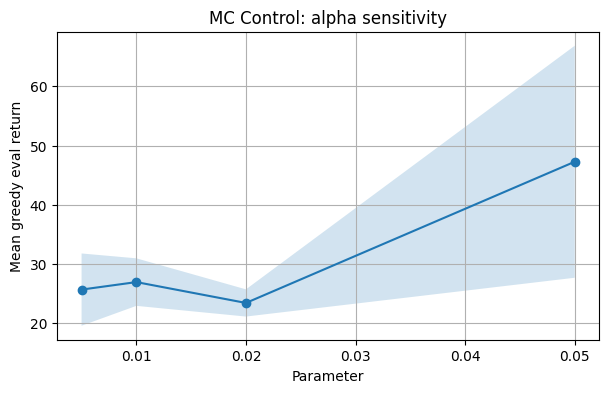

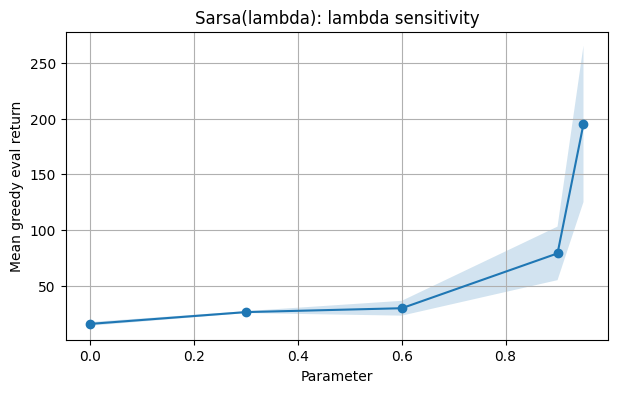

In [13]:
mc_alpha_grid = [0.005, 0.01, 0.02, 0.05]
sarsa_lambda_grid = [0.0, 0.3, 0.6, 0.9, 0.95]

mc_sweep = sweep_mc_alpha(mc_alpha_grid, n_episodes=1500, n_runs=N_RUNS)
sarsa_sweep = sweep_sarsa_lambda(sarsa_lambda_grid, n_episodes=1500, n_runs=N_RUNS)

plot_sweep_mean_return(mc_sweep, "MC Control: alpha sensitivity")
plot_sweep_mean_return(sarsa_sweep, "Sarsa(lambda): lambda sensitivity")



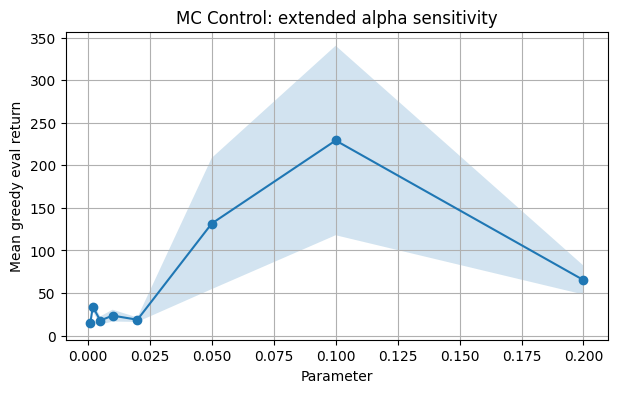

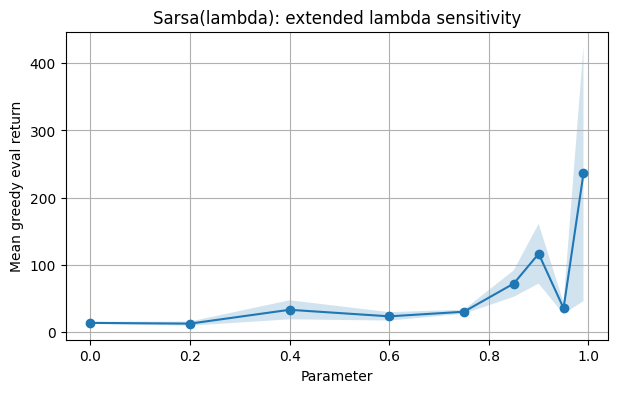

Best MC alpha (extended sweep): 0.1 -> 229.16 +/- 111.31
Best Sarsa lambda (extended sweep): 0.99 -> 236.12 +/- 189.81


In [14]:
# Extended sweep (broader parameter ranges)
# Tip: start with quick mode, then increase n_runs/n_episodes for final report figures.

QUICK_SWEEP_RUNS = 3
QUICK_SWEEP_EPISODES = 1000

mc_alpha_grid_ext = [0.001, 0.002, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2]
sarsa_lambda_grid_ext = [0.0, 0.2, 0.4, 0.6, 0.75, 0.85, 0.9, 0.95, 0.99]

mc_sweep_ext = sweep_mc_alpha(mc_alpha_grid_ext, n_episodes=QUICK_SWEEP_EPISODES, n_runs=QUICK_SWEEP_RUNS)
sarsa_sweep_ext = sweep_sarsa_lambda(sarsa_lambda_grid_ext, n_episodes=QUICK_SWEEP_EPISODES, n_runs=QUICK_SWEEP_RUNS)

plot_sweep_mean_return(mc_sweep_ext, "MC Control: extended alpha sensitivity")
plot_sweep_mean_return(sarsa_sweep_ext, "Sarsa(lambda): extended lambda sensitivity")

best_mc_alpha = max(mc_sweep_ext, key=lambda a: mc_sweep_ext[a]["mean"])
best_sarsa_lambda = max(sarsa_sweep_ext, key=lambda lam: sarsa_sweep_ext[lam]["mean"])

print("Best MC alpha (extended sweep):", best_mc_alpha, "->", round(mc_sweep_ext[best_mc_alpha]["mean"], 2), "+/-", round(mc_sweep_ext[best_mc_alpha]["sem"], 2))
print("Best Sarsa lambda (extended sweep):", best_sarsa_lambda, "->", round(sarsa_sweep_ext[best_sarsa_lambda]["mean"], 2), "+/-", round(sarsa_sweep_ext[best_sarsa_lambda]["sem"], 2))



## 8) Generalization Test Across Configurations
We test robustness by training on the source configuration (height=15, width=20, pipe_gap=4) and evaluating on different environment configurations. This measures out-of-distribution transfer.

In [15]:
# Generalization with best params from extended sweep
# Uses best_mc_alpha and best_sarsa_lambda computed in the extended sweep cell.

final_mc_alpha = best_mc_alpha
final_sarsa_lambda = best_sarsa_lambda
final_sarsa_alpha = sarsa_params["alpha"]  # keep alpha fixed unless you run a 2D (alpha, lambda) sweep

Q_mc_best, _ = mc_control(
    ENV_CONFIG,
    N_EPISODES,
    alpha=final_mc_alpha,
    epsilon=mc_params["epsilon"],
    gamma=GAMMA,
    seed=SEED + 999,
    max_steps_per_episode=MAX_STEPS_PER_EPISODE,
)

Q_sarsa_best, _ = sarsa_lambda_control(
    ENV_CONFIG,
    N_EPISODES,
    alpha=final_sarsa_alpha,
    epsilon=sarsa_params["epsilon"],
    lam=final_sarsa_lambda,
    gamma=GAMMA,
    seed=SEED + 1999,
    max_steps_per_episode=MAX_STEPS_PER_EPISODE,
)

print("Generalization uses:")
print("- MC alpha:", final_mc_alpha)
print("- Sarsa alpha:", final_sarsa_alpha, "lambda:", final_sarsa_lambda)

test_configs = [
    {"height": 15, "width": 20, "pipe_gap": 4},  # train config
    {"height": 15, "width": 20, "pipe_gap": 5},
    {"height": 16, "width": 22, "pipe_gap": 4},
]

rows = []
for cfg in test_configs:
    mc_eval = evaluate_greedy_policy(Q_mc_best, cfg, n_episodes=100, seed=SEED + 77, max_steps_per_episode=MAX_STEPS_PER_EPISODE)
    s_eval = evaluate_greedy_policy(Q_sarsa_best, cfg, n_episodes=100, seed=SEED + 77, max_steps_per_episode=MAX_STEPS_PER_EPISODE)
    rows.append((cfg, mc_eval["mean_return"], s_eval["mean_return"]))

for cfg, mc_r, s_r in rows:
    print(cfg, "-> MC:", round(mc_r, 2), "| Sarsa(lambda):", round(s_r, 2))



Generalization uses:
- MC alpha: 0.1
- Sarsa alpha: 0.08 lambda: 0.99
{'height': 15, 'width': 20, 'pipe_gap': 4} -> MC: 201.86 | Sarsa(lambda): 578.28
{'height': 15, 'width': 20, 'pipe_gap': 5} -> MC: 473.93 | Sarsa(lambda): 1000.0
{'height': 16, 'width': 22, 'pipe_gap': 4} -> MC: 90.09 | Sarsa(lambda): 300.13


## 8-bis) Generalization (Multi-Run, Final Protocol)

This section repeats generalization with multiple retrainings to reduce seed sensitivity.
It reports mean and standard deviation across independent runs for each test configuration.



In [16]:
# Multi-run generalization for robust reporting
FINAL_GEN_RUNS = 10
FINAL_GEN_EVAL_EPISODES = 100

# Uses best params from extended sweep
final_mc_alpha = best_mc_alpha
final_sarsa_lambda = best_sarsa_lambda
final_sarsa_alpha = sarsa_params["alpha"]
final_epsilon = mc_params["epsilon"]  # same epsilon used for both agents in this notebook

gen_results = []
for cfg in test_configs:
    mc_scores = []
    sarsa_scores = []

    for run_idx in range(FINAL_GEN_RUNS):
        run_seed = SEED + 5000 + run_idx

        # Retrain with final parameters on train configuration
        Q_mc_run, _ = mc_control(
            ENV_CONFIG,
            N_EPISODES,
            alpha=final_mc_alpha,
            epsilon=final_epsilon,
            gamma=GAMMA,
            seed=run_seed,
            max_steps_per_episode=MAX_STEPS_PER_EPISODE,
        )

        Q_sarsa_run, _ = sarsa_lambda_control(
            ENV_CONFIG,
            N_EPISODES,
            alpha=final_sarsa_alpha,
            epsilon=final_epsilon,
            lam=final_sarsa_lambda,
            gamma=GAMMA,
            seed=run_seed,
            max_steps_per_episode=MAX_STEPS_PER_EPISODE,
        )

        mc_eval = evaluate_greedy_policy(
            Q_mc_run,
            cfg,
            n_episodes=FINAL_GEN_EVAL_EPISODES,
            seed=SEED + 6000 + run_idx,
            max_steps_per_episode=MAX_STEPS_PER_EPISODE,
        )
        s_eval = evaluate_greedy_policy(
            Q_sarsa_run,
            cfg,
            n_episodes=FINAL_GEN_EVAL_EPISODES,
            seed=SEED + 7000 + run_idx,
            max_steps_per_episode=MAX_STEPS_PER_EPISODE,
        )

        mc_scores.append(mc_eval["mean_return"])
        sarsa_scores.append(s_eval["mean_return"])

    gen_results.append({
        "config": cfg,
        "mc_mean": float(np.mean(mc_scores)),
        "mc_std": float(np.std(mc_scores, ddof=1)) if len(mc_scores) > 1 else 0.0,
        "sarsa_mean": float(np.mean(sarsa_scores)),
        "sarsa_std": float(np.std(sarsa_scores, ddof=1)) if len(sarsa_scores) > 1 else 0.0,
    })

print("Final generalization (multi-run):")
for r in gen_results:
    print(
        r["config"],
        "-> MC:", round(r["mc_mean"], 2), "+/-", round(r["mc_std"], 2),
        "| Sarsa(lambda):", round(r["sarsa_mean"], 2), "+/-", round(r["sarsa_std"], 2),
    )



Final generalization (multi-run):
{'height': 15, 'width': 20, 'pipe_gap': 4} -> MC: 201.56 +/- 292.12 | Sarsa(lambda): 375.92 +/- 269.57
{'height': 15, 'width': 20, 'pipe_gap': 5} -> MC: 439.46 +/- 297.94 | Sarsa(lambda): 687.92 +/- 384.57
{'height': 16, 'width': 22, 'pipe_gap': 4} -> MC: 131.44 +/- 103.43 | Sarsa(lambda): 235.45 +/- 146.0


## 8-ter) Final Train-Config Evaluation (Multi-Run, Final Hyperparameters)

This block evaluates both agents on the training configuration using the final selected hyperparameters,
so the summary table is protocol-consistent.



In [17]:
# Multi-run train-config evaluation with final selected hyperparameters
FINAL_TRAIN_RUNS = 10
FINAL_TRAIN_EVAL_EPISODES = 100

mc_train_scores_final = []
sarsa_train_scores_final = []

for run_idx in range(FINAL_TRAIN_RUNS):
    run_seed = SEED + 8000 + run_idx

    Q_mc_run, _ = mc_control(
        ENV_CONFIG,
        N_EPISODES,
        alpha=final_mc_alpha,
        epsilon=final_epsilon,
        gamma=GAMMA,
        seed=run_seed,
        max_steps_per_episode=MAX_STEPS_PER_EPISODE,
    )

    Q_sarsa_run, _ = sarsa_lambda_control(
        ENV_CONFIG,
        N_EPISODES,
        alpha=final_sarsa_alpha,
        epsilon=final_epsilon,
        lam=final_sarsa_lambda,
        gamma=GAMMA,
        seed=run_seed,
        max_steps_per_episode=MAX_STEPS_PER_EPISODE,
    )

    mc_eval = evaluate_greedy_policy(
        Q_mc_run,
        ENV_CONFIG,
        n_episodes=FINAL_TRAIN_EVAL_EPISODES,
        seed=SEED + 9000 + run_idx,
        max_steps_per_episode=MAX_STEPS_PER_EPISODE,
    )
    s_eval = evaluate_greedy_policy(
        Q_sarsa_run,
        ENV_CONFIG,
        n_episodes=FINAL_TRAIN_EVAL_EPISODES,
        seed=SEED + 10000 + run_idx,
        max_steps_per_episode=MAX_STEPS_PER_EPISODE,
    )

    mc_train_scores_final.append(mc_eval["mean_return"])
    sarsa_train_scores_final.append(s_eval["mean_return"])

mc_train_eval_mean_final = float(np.mean(mc_train_scores_final))
mc_train_eval_std_final = float(np.std(mc_train_scores_final, ddof=1)) if len(mc_train_scores_final) > 1 else 0.0
s_train_eval_mean_final = float(np.mean(sarsa_train_scores_final))
s_train_eval_std_final = float(np.std(sarsa_train_scores_final, ddof=1)) if len(sarsa_train_scores_final) > 1 else 0.0

print("Final train-config eval (multi-run):")
print("MC Control:", round(mc_train_eval_mean_final, 2), "+/-", round(mc_train_eval_std_final, 2))
print("Sarsa(lambda):", round(s_train_eval_mean_final, 2), "+/-", round(s_train_eval_std_final, 2))



Final train-config eval (multi-run):
MC Control: 385.69 +/- 316.58
Sarsa(lambda): 622.68 +/- 228.06


## 9-bis) Final Summary Table

Compact summary of the chosen final hyperparameters and key metrics for the report.



In [18]:
# Final summary table (plain text, report-ready)

# Use final-protocol train metrics if available; fallback to baseline metrics otherwise
if "mc_train_eval_mean_final" in globals():
    mc_train_eval_mean = mc_train_eval_mean_final
    mc_train_eval_std = mc_train_eval_std_final
    s_train_eval_mean = s_train_eval_mean_final
    s_train_eval_std = s_train_eval_std_final
else:
    mc_train_eval_mean = float(np.mean(mc_means))
    mc_train_eval_std = float(np.std(mc_means, ddof=1)) if len(mc_means) > 1 else 0.0
    s_train_eval_mean = float(np.mean(sarsa_means))
    s_train_eval_std = float(np.std(sarsa_means, ddof=1)) if len(sarsa_means) > 1 else 0.0

print("=" * 105)
print("FINAL SUMMARY")
print("=" * 105)
print("Agent | Final Hyperparameters | Train-config Eval (mean +/- std)")
print("-" * 105)
print(f"MC Control | alpha={final_mc_alpha}, epsilon={final_epsilon}, gamma={GAMMA} | {mc_train_eval_mean:.2f} +/- {mc_train_eval_std:.2f}")
print(f"Sarsa(lambda) | alpha={final_sarsa_alpha}, lambda={final_sarsa_lambda}, epsilon={final_epsilon}, gamma={GAMMA} | {s_train_eval_mean:.2f} +/- {s_train_eval_std:.2f}")
print("-" * 105)
print("Generalization (multi-run)")
for r in gen_results:
    cfg = r["config"]
    print(
        f"cfg={cfg} | MC: {r['mc_mean']:.2f} +/- {r['mc_std']:.2f} | "
        f"Sarsa(lambda): {r['sarsa_mean']:.2f} +/- {r['sarsa_std']:.2f}"
    )



FINAL SUMMARY
Agent | Final Hyperparameters | Train-config Eval (mean +/- std)
---------------------------------------------------------------------------------------------------------
MC Control | alpha=0.1, epsilon=0.1, gamma=0.99 | 385.69 +/- 316.58
Sarsa(lambda) | alpha=0.08, lambda=0.99, epsilon=0.1, gamma=0.99 | 622.68 +/- 228.06
---------------------------------------------------------------------------------------------------------
Generalization (multi-run)
cfg={'height': 15, 'width': 20, 'pipe_gap': 4} | MC: 201.56 +/- 292.12 | Sarsa(lambda): 375.92 +/- 269.57
cfg={'height': 15, 'width': 20, 'pipe_gap': 5} | MC: 439.46 +/- 297.94 | Sarsa(lambda): 687.92 +/- 384.57
cfg={'height': 16, 'width': 22, 'pipe_gap': 4} | MC: 131.44 +/- 103.43 | Sarsa(lambda): 235.45 +/- 146.00
